## Company ESG Financial Analysis

In this notebook I am exploring the relationship between how ESG metrics effect financial performance using the Kaggle ESG & Financial Performance Dataset.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
warnings.filterwarnings("ignore")

df = pd.read_csv("company_esg_financial_dataset.csv")

print(df.columns) 
print()
print("Missing values from columns:")
print(df.isnull().sum())

Index(['CompanyID', 'CompanyName', 'Industry', 'Region', 'Year', 'Revenue',
       'ProfitMargin', 'MarketCap', 'GrowthRate', 'ESG_Overall',
       'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'CarbonEmissions',
       'WaterUsage', 'EnergyConsumption'],
      dtype='object')

Missing values from columns:
CompanyID               0
CompanyName             0
Industry                0
Region                  0
Year                    0
Revenue                 0
ProfitMargin            0
MarketCap               0
GrowthRate           1000
ESG_Overall             0
ESG_Environmental       0
ESG_Social              0
ESG_Governance          0
CarbonEmissions         0
WaterUsage              0
EnergyConsumption       0
dtype: int64


### ESG Overall Score vs. Revenue

Looks at the relationship between a companies overall ESG score and its revenue.

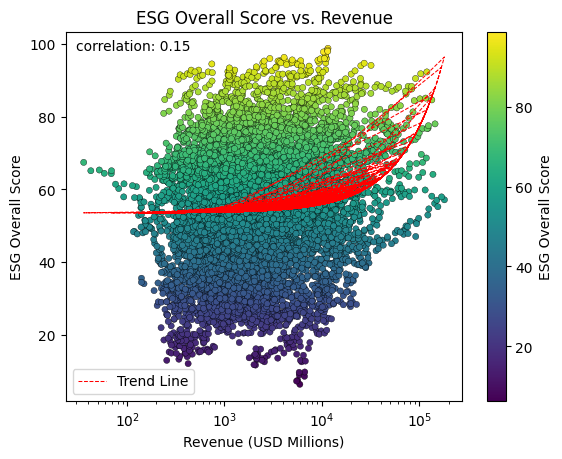

In [81]:
scatter = plt.scatter(df['Revenue'], 
                     df['ESG_Overall'],
                     c=df['ESG_Overall'],
                     edgecolors='black', 
                     linewidth = 0.25,
                     s = 20
)

plt.colorbar(scatter, label='ESG Overall Score')

z = np.polyfit(df['Revenue'],
            df['ESG_Overall'],
            1
)

p = np.poly1d(z)

plt.plot(df['Revenue'], p(df['Revenue']), "r--", linewidth = 0.75, label='Trend Line')
plt.title('ESG Overall Score vs. Revenue')
plt.xlabel('Revenue (USD Millions)')
plt.ylabel('ESG Overall Score')
plt.xscale('log')

correlation = df['Revenue'].corr(df['ESG_Overall'])
plt.text(0.025, 0.95, f'correlation: {correlation:.2f}', transform=plt.gca().transAxes)

plt.legend()
plt.show()


### ESG Factors vs. Revenue

Looks at the relationship between companies individual ESG scores and its revenue.

In [90]:
corr = df[['Revenue', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance']].corr()
print(corr['Revenue'])

Revenue              1.000000
ESG_Environmental    0.206628
ESG_Social           0.047173
ESG_Governance       0.018489
Name: Revenue, dtype: float64


Among the three factors, enviornment score 0.21 has the strongest , although weak, linear relationship with Revenue; Social 0.05 and Goverance 0.02 show almost no linear correlation. Note that lareger companies might tent to have higher enviornmental and scores and higher revenue just because they are large, not because one causes the other

### ESG Overall by Industry

Looks at the overall ESG Scores by industry.

Industry
Transportation    46.034499
Energy            49.014815
Manufacturing     50.462626
Utilities         51.601274
Consumer Goods    54.829467
Retail            55.681818
Healthcare        57.254395
Technology        63.345167
Finance           64.620434
Name: ESG_Overall, dtype: float64

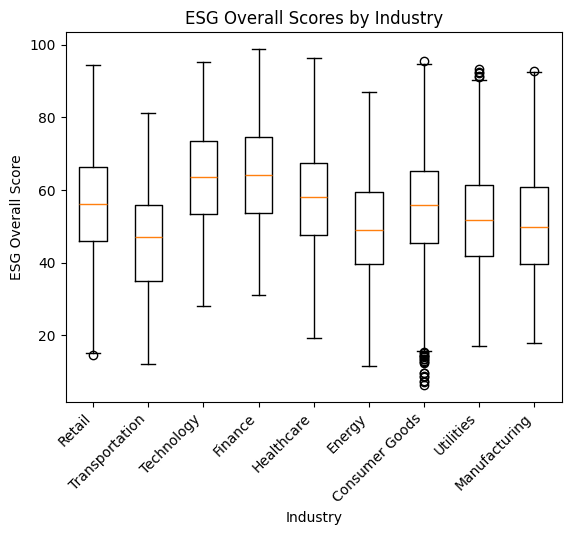

In [100]:
industries = df['Industry'].dropna().unique()
data = [df[df['Industry']== industry]['ESG_Overall'].dropna() for industry in industries]

bp = plt.boxplot(data,
                 labels = industries)

plt.title('ESG Overall Scores by Industry')
plt.xlabel('Industry')
plt.ylabel('ESG Overall Score')
plt.xticks(rotation=45, ha='right')


mean_scores = df.groupby('Industry')['ESG_Overall'].mean().sort_values()
mean_scores.columns = ['Industry', 'Mean_ESG_Overall']
mean_scores

### ESG Overall Trend from 2015-2025

Looks at the average ESG Overall score from the years 2015 to 2025.

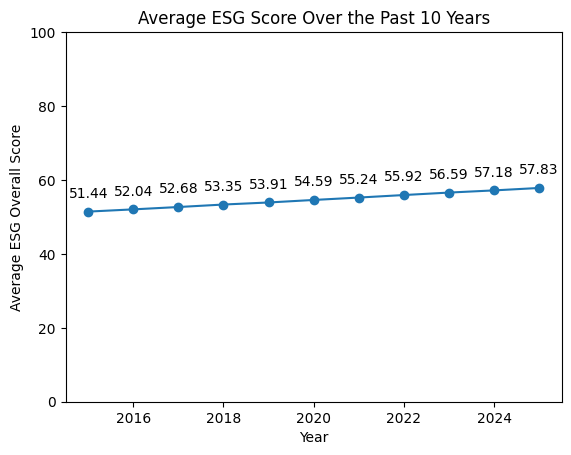

In [109]:
avg_esg_by_year = df.groupby('Year')['ESG_Overall'].mean()

plt.plot(avg_esg_by_year.index, avg_esg_by_year.values, marker = 'o')
plt.title('Average ESG Score Over the Past 10 Years')
plt.xlabel('Year')
plt.ylabel('Average ESG Overall Score')
plt.ylim(0, 100)

for year, avg_score in avg_esg_by_year.items():
    plt.annotate(f'{avg_score:.2f}',
                 (year, avg_score),
                 xytext=(0,10),
                 textcoords='offset points',
                 ha = 'center')